In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
df = pd.read_csv('Airbnb.csv',low_memory=False,encoding='latin-1')

ACCESS THE DATA

In [3]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,19-10-2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,21-05-2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,05-07-2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,19-11-2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [5]:
df.duplicated().value_counts()

False    102058
True        541
Name: count, dtype: int64

In [6]:
#Remove duplicate records
df.drop_duplicates(inplace=True)
#Drop house_rules and license columns with insufficient data
df.drop(['house_rules','license'],axis=1,inplace=True)
#Remove all dollar signs in the price and service fee columns
df['price'] = df['price'].str.replace('$','',regex=False)
df['service fee'] = df['service fee'].str.replace('$','',regex=False)
#Remove all commas in the price and service fee columns
df['price'] = df['price'].str.replace(',','',regex=False)
df['service fee'] = df['service fee'].str.replace(',','',regex=False)
#Rename the price and service fee columns to include a dollar sign
df.rename(columns={'price':'price_$','service fee':'service_fee_$'},inplace=True)
#Drop all records with missing value
df.dropna(inplace=True)
#change all mismatched data types to the appropriate once
df['price_$'] = df['price_$'].astype(float)
df['service_fee_$'] = df['service_fee_$'].astype(float)
df['id']=df['id'].astype(str)
df['host id']=df['host id'].astype(str) # Keep the original column name for now
df['last review']=pd.to_datetime(df['last review'])
df['Construction year']=df['Construction year'].astype(int)
#Correct the spelling of'brookln' to Brooklyn'
df.loc[df['neighbourhood group']=='brookln','neighbourhood group']='Brooklyn'
#Get rid of outliers in the'availability 365' column data
df=df.drop(df[df['availability 365']>500].index)

C:\Users\FAB\AppData\Local\Temp\ipykernel_5228\1851908853.py:20: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['last review']=pd.to_datetime(df['last review'])


In [7]:
df.duplicated().value_counts()

False    83411
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83411 entries, 0 to 102040
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              83411 non-null  object        
 1   NAME                            83411 non-null  object        
 2   host id                         83411 non-null  object        
 3   host_identity_verified          83411 non-null  object        
 4   host name                       83411 non-null  object        
 5   neighbourhood group             83411 non-null  object        
 6   neighbourhood                   83411 non-null  object        
 7   lat                             83411 non-null  float64       
 8   long                            83411 non-null  float64       
 9   country                         83411 non-null  object        
 10  country code                    83411 non-null  object        
 11  instan

In [9]:
df.describe()

,lat,long,Construction year,price_$,service_fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,83411.000000,83411.000000,83411.000000,83411.000000,83411.000000,83411.000000,83411.000000,83411,83411.000000,83411.000000,83411.000000,83411.000000
mean,40.727353,-73.948500,2012.488509,626.212730,125.243709,7.405366,32.276642,2019-06-08 22:01:01.027922176,1.377584,3.278776,7.032682,141.742612
min,40.504560,-74.249840,2003.000000,50.000000,10.000000,-365.000000,1.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,40.687650,-73.982110,2007.000000,340.000000,68.000000,2.000000,3.000000,2018-10-26 00:00:00,0.220000,2.000000,1.000000,6.000000
50%,40.721320,-73.953720,2012.000000,625.000000,125.000000,3.000000,11.000000,2019-06-13 00:00:00,0.740000,3.000000,1.000000,101.000000
75%,40.762595,-73.930815,2017.000000,914.000000,183.000000,5.000000,38.000000,2019-07-05 00:00:00,2.010000,4.000000,2.000000,266.000000
max,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2022-05-21 00:00:00,90.000000,5.000000,332.000000,426.000000
std,0.056324,0.050347,5.760870,331.787179,66.360979,28.102221,51.957777,NaN,1.751041,1.283599,29.551590,133.368399


In [10]:
#What are the different property types in the Dataset?
property_types=df['room type'].value_counts().to_frame()
property_types

,count
room type,
Entire home/apt,44163
Private room,37494
Shared room,1646
Hotel room,108


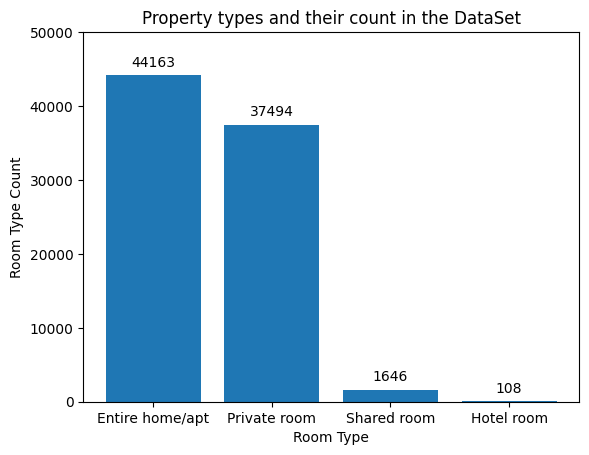

In [11]:
room_type_bar=plt.bar(property_types.index,property_types.loc[:,"count"]);
plt.bar_label(room_type_bar,labels=property_types.loc[:,"count"],padding=4);
plt.ylim([0,50000]);
plt.xlabel('Room Type');
plt.ylabel('Room Type Count');
plt.title('Room Type Distribution');
plt.title('Property types and their count in the DataSet');


In [12]:
hood_group=df['neighbourhood group'].value_counts().to_frame()
hood_group

,count
neighbourhood group,
Brooklyn,34636
Manhattan,34566
Queens,11126
Bronx,2267
Staten Island,816


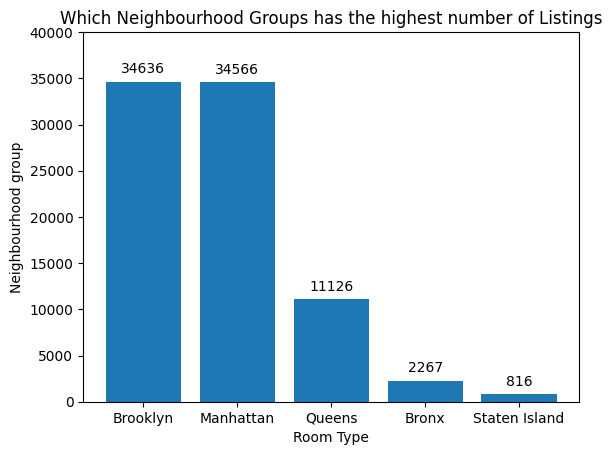

In [13]:
hood_group_bar=plt.bar(hood_group.index,hood_group.loc[:,"count"]);
plt.bar_label(hood_group_bar,labels=hood_group.loc[:,"count"],padding=4);
plt.ylim([0,40000]);
plt.xlabel('Room Type');
plt.ylabel('Neighbourhood group');
plt.title('Number of listings');
plt.title('Which Neighbourhood Groups has the highest number of Listings');


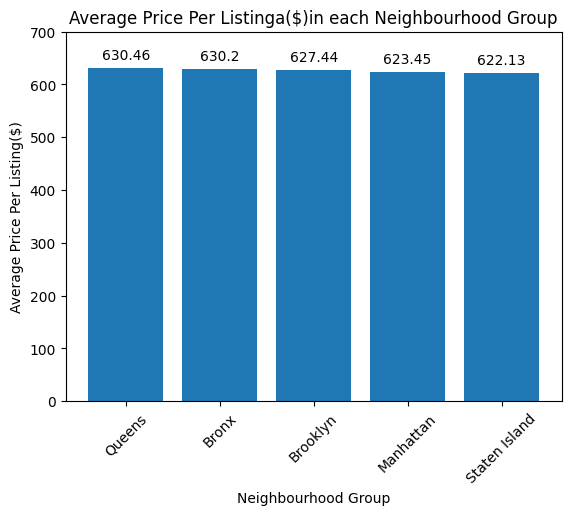

In [14]:
avg_price=df.groupby('neighbourhood group')['price_$'].mean().sort_values(ascending=False).to_frame()
avg_price_bar=plt.bar(avg_price.index,avg_price.loc[:,"price_$"]);
plt.bar_label(avg_price_bar,labels=round(avg_price.loc[:,"price_$"],2),label_type='edge',padding=4);
plt.ylim([0,700]);
plt.xlabel('Neighbourhood Group');
plt.ylabel('Average Price Per Listing($)');
plt.xticks(rotation=45);
plt.title('Average Price Per Listinga($)in each Neighbourhood Group');

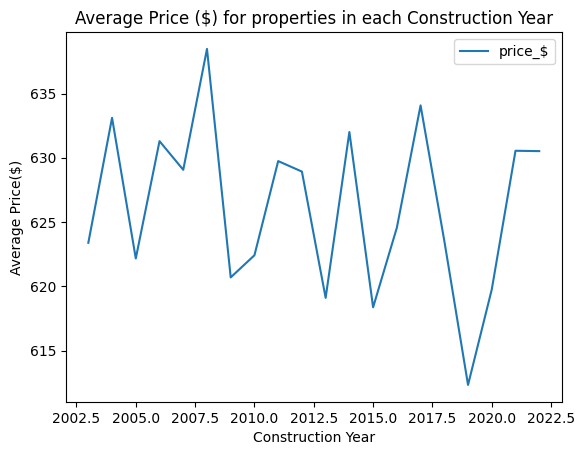

In [15]:
#Isthere a relationship between the construction year of property and price?
df.groupby(df['Construction year'])['price_$'].mean().to_frame().plot();
plt.xlabel('Construction Year');
plt.ylabel('Average Price($)');
plt.title('Average Price ($) for properties in each Construction Year');


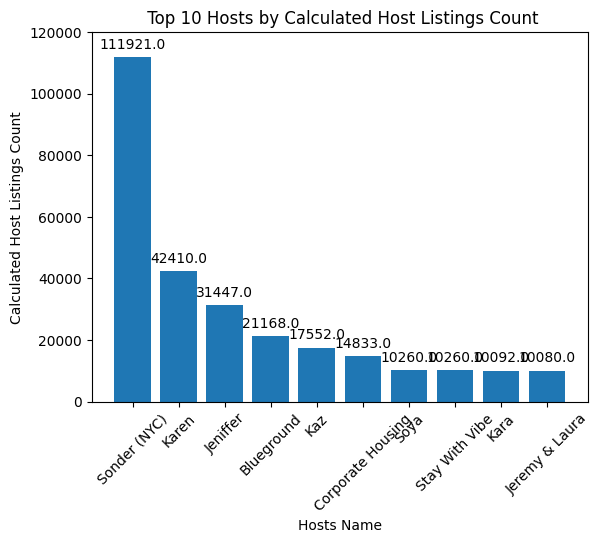

In [16]:
#who are the top 10 hosts by calculated host listing count?
hosts=df.groupby('host name')['calculated host listings count'].sum().sort_values(ascending=False).nlargest(10).to_frame()
hosts_bar=plt.bar(hosts.index,hosts.loc[:,"calculated host listings count"]);
plt.bar_label(hosts_bar,labels=hosts.loc[:,"calculated host listings count"],label_type='edge',padding=4);
plt.xlabel('Hosts Name');
plt.ylabel('Calculated Host Listings Count');
plt.title('Top 10 Hosts by Calculated Host Listings Count');
plt.xticks(rotation=45);
plt.ylim([0,120000]);
plt.title(' Top 10 Hosts by Calculated Host Listings Count');



Are hosts with verified identities more likely to recieve positive reviews?

In [17]:
review=df.groupby('host_identity_verified')['review rate number'].mean().sort_values(ascending=False).to_frame()
review

,review rate number
host_identity_verified,
verified,3.284186
unconfirmed,3.273370


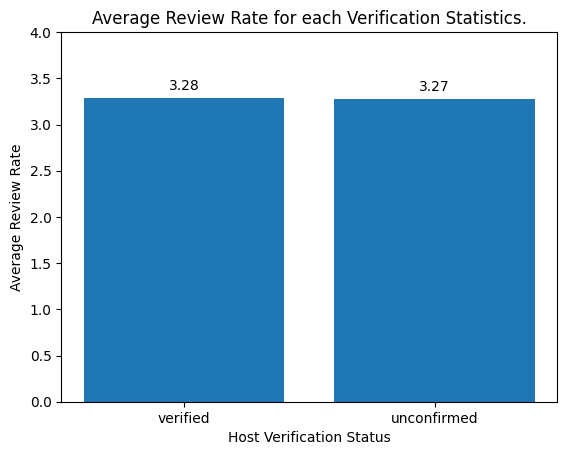

In [18]:
review_bar=plt.bar(review.index,review.loc[:,"review rate number"]);
plt.bar_label(review_bar,labels=round(review.loc[:,"review rate number"],2),padding=4);
plt.ylim([0,4]);
plt.xlabel('Host Verification Status')
plt.ylabel('Average Review Rate')
plt.title('Average Review Rate for each Verification Statistics.');

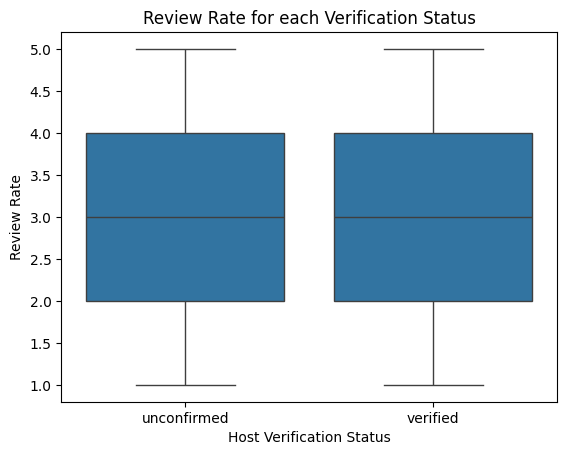

In [19]:
base_color = sns.color_palette()[0]
sns.boxplot(data=df,x="host_identity_verified",y="review rate number",color=base_color);
plt.xlabel('Host Verification Status');
plt.ylabel('Review Rate');
plt.title('Review Rate for each Verification Status');


Is there a correlation between the price of a listing and its service fee

In [20]:
df['price_$'].corr(df['service_fee_$'])


np.float64(0.9999909074778277)

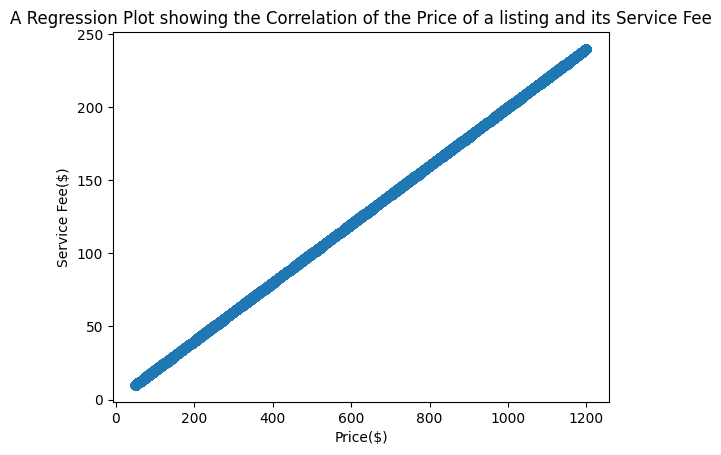

In [21]:
sns.regplot(df,x='price_$',y='service_fee_$');
plt.xlabel('Price($)');
plt.ylabel('Service Fee($)');
plt.title('A Regression Plot showing the Correlation of the Price of a listing and its Service Fee');

What is the average review rate number(e.g., stars) for listings , and does it vary based on neighborhood group and room type?

In [22]:
ARRN=df.groupby(['neighbourhood group','room type'])['review rate number'].mean().to_frame()
ARRN

review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            3.381881
                    Private room               3.305810
                    Shared room                3.356322
Brooklyn            Entire home/apt            3.242491
                    Hotel room                 3.833333
                    Private room               3.274905
                    Shared room                3.323383
Manhattan           Entire home/apt            3.268846
                    Hotel room                 3.500000
                    Private room               3.285605
                    Shared room                3.261976
Queens              Entire home/apt            3.350045
                    Hotel room                 3.750000
                    Private room               3.310847
                    Shared room                3.327402
Staten Island       Entire home/apt            3.333333
                    Private room               3.497449
                    Shared room                3.714286

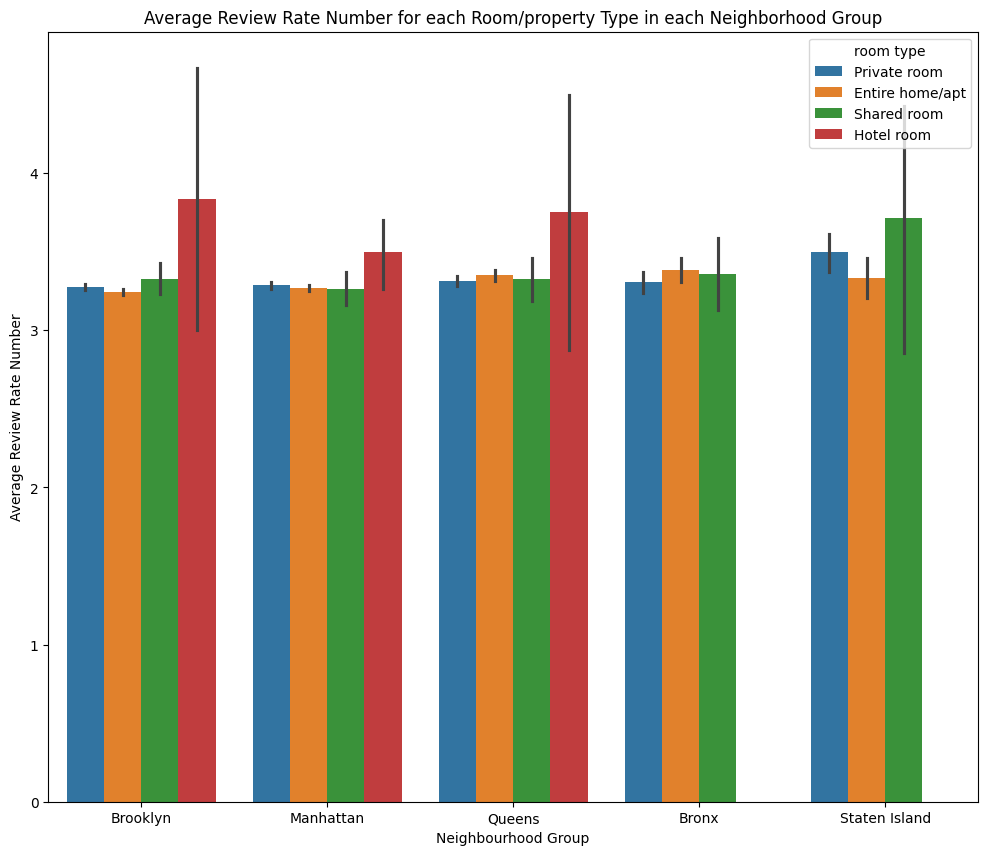

In [23]:
plt.figure(figsize=[12,10]);
sns.barplot(data=df,x='neighbourhood group',y='review rate number',hue='room type');
plt.xlabel('Neighbourhood Group');
plt.ylabel('Average Review Rate Number');
plt.title('Average Review Rate Number for each Room/property Type in each Neighborhood Group');


Are hosts with higher calculated host listings count more likely to maintain higher availability throughout the year?

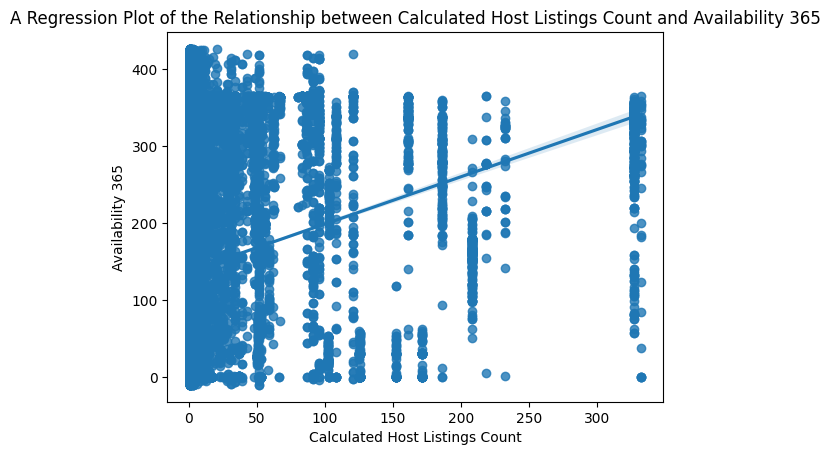

In [24]:
sns.regplot(df,x='calculated host listings count',y='availability 365');
plt.xlabel('Calculated Host Listings Count');
plt.ylabel('Availability 365');
plt.title('A Regression Plot of the Relationship between Calculated Host Listings Count and Availability 365');

In [25]:
df['calculated host listings count'].corr(df['availability 365'])


np.float64(0.13598552736758687)

The pearson correlation coefficient for the association between calculated host listings and availability is 0.136 , indicating a weak positive correlation between the two variables

## Seasonality and Demand Proxies
We do not have explicit booking dates or lead times. As a proxy for demand over time, we use `reviews per month` and the month of `last review`. While imperfect, peaks in the distribution of `last review` months and higher `reviews per month` values can indicate periods and locations with stronger guest activity.


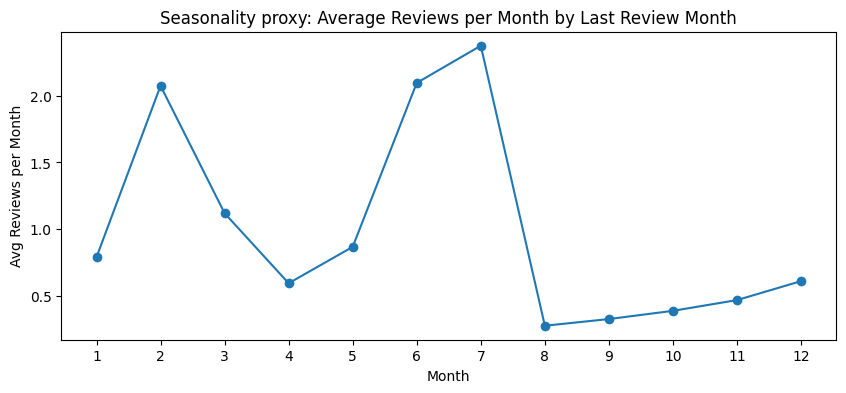

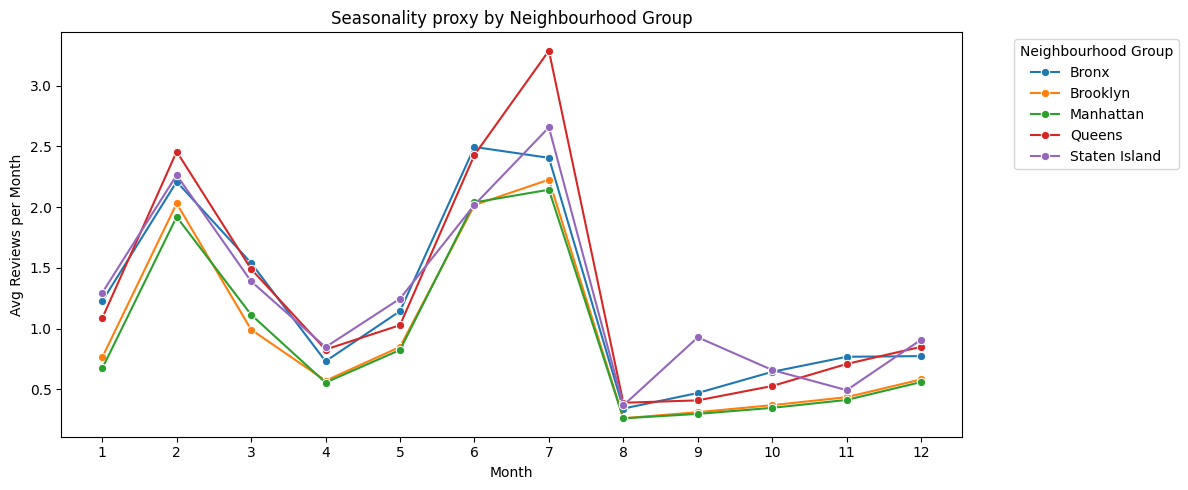

Lead-time analysis requires booking or check-in dates, which are not present.


In [26]:
# Create month features from last review
activity = df.copy()
activity['last_review_month'] = activity['last review'].dt.month
activity['last_review_year'] = activity['last review'].dt.year

# Seasonality by month across all locations
seasonality = (
    activity.groupby('last_review_month')['reviews per month']
    .mean()
    .reindex(range(1,13))
)
plt.figure(figsize=(10,4))
seasonality.plot(marker='o')
plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Avg Reviews per Month')
plt.title('Seasonality proxy: Average Reviews per Month by Last Review Month')
plt.show()

# Variation by location (neighbourhood group) and month
loc_month = (
    activity.groupby(['neighbourhood group','last_review_month'])['reviews per month']
    .mean()
    .reset_index()
)
plt.figure(figsize=(12,5))
sns.lineplot(data=loc_month, x='last_review_month', y='reviews per month', hue='neighbourhood group', marker='o')
plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Avg Reviews per Month')
plt.title('Seasonality proxy by Neighbourhood Group')
plt.legend(title='Neighbourhood Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Lead-time proxy is not available without booking/check-in dates.
print('Lead-time analysis requires booking or check-in dates, which are not present.')


## Pricing Impact on Demand and Satisfaction
We examine whether price relates to demand (`reviews per month`) and satisfaction (`review rate number`). We compute correlations and visualize relationships by `room type` and `neighbourhood group`.


Correlation(price, reviews_per_month): 0.004
Correlation(price, review_rate_number): -0.007


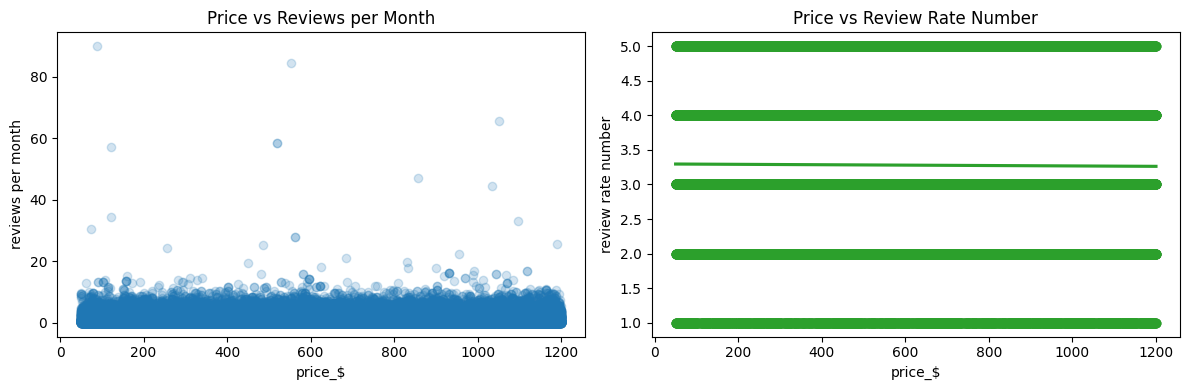

<Figure size 1200x400 with 0 Axes>

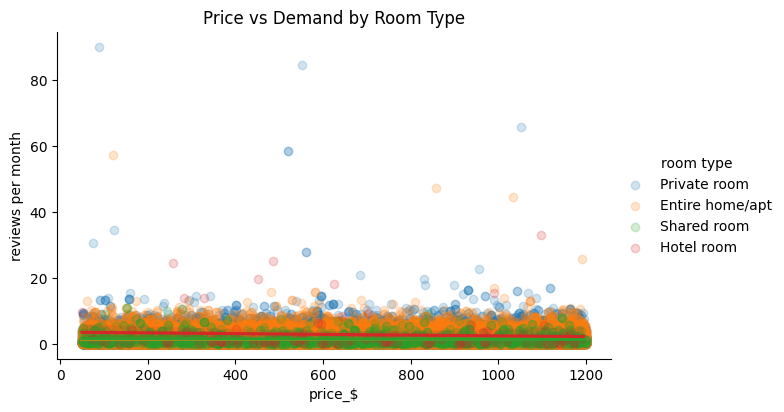

<Figure size 1200x400 with 0 Axes>

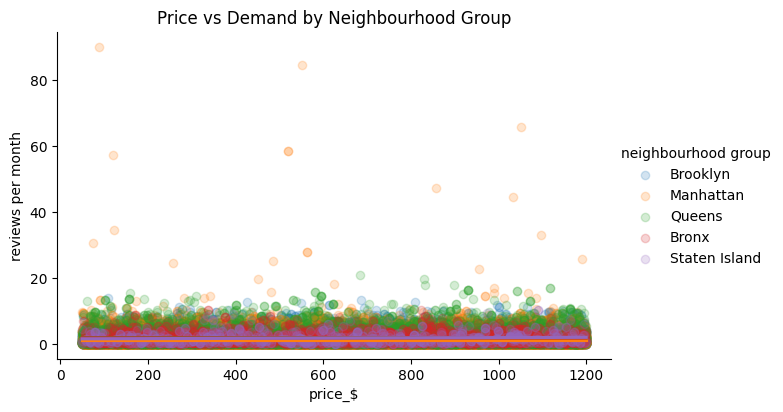

In [27]:
# Correlations
price_demand_corr = df['price_$'].corr(df['reviews per month'])
price_rating_corr = df['price_$'].corr(df['review rate number'])
print(f'Correlation(price, reviews_per_month): {price_demand_corr:.3f}')
print(f'Correlation(price, review_rate_number): {price_rating_corr:.3f}')

# Scatterplots with trend lines
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.regplot(data=df, x='price_$', y='reviews per month', scatter_kws={'alpha':0.2}, color='tab:blue')
plt.title('Price vs Reviews per Month')
plt.subplot(1,2,2)
sns.regplot(data=df, x='price_$', y='review rate number', scatter_kws={'alpha':0.2}, color='tab:green')
plt.title('Price vs Review Rate Number')
plt.tight_layout()
plt.show()

# Relationship stratified by room type
plt.figure(figsize=(12,4))
sns.lmplot(data=df, x='price_$', y='reviews per month', hue='room type', height=4, aspect=1.6, scatter_kws={'alpha':0.2})
plt.title('Price vs Demand by Room Type')
plt.show()

# Relationship stratified by neighbourhood group
plt.figure(figsize=(12,4))
sns.lmplot(data=df, x='price_$', y='reviews per month', hue='neighbourhood group', height=4, aspect=1.6, scatter_kws={'alpha':0.2})
plt.title('Price vs Demand by Neighbourhood Group')
plt.show()


## Guest Preference Proxies
We approximate guest preferences using higher demand (`reviews per month`) and higher ratings (`review rate number`) by `room type`, `neighbourhood group`, and booking options like `instant_bookable` and `cancellation_policy`.


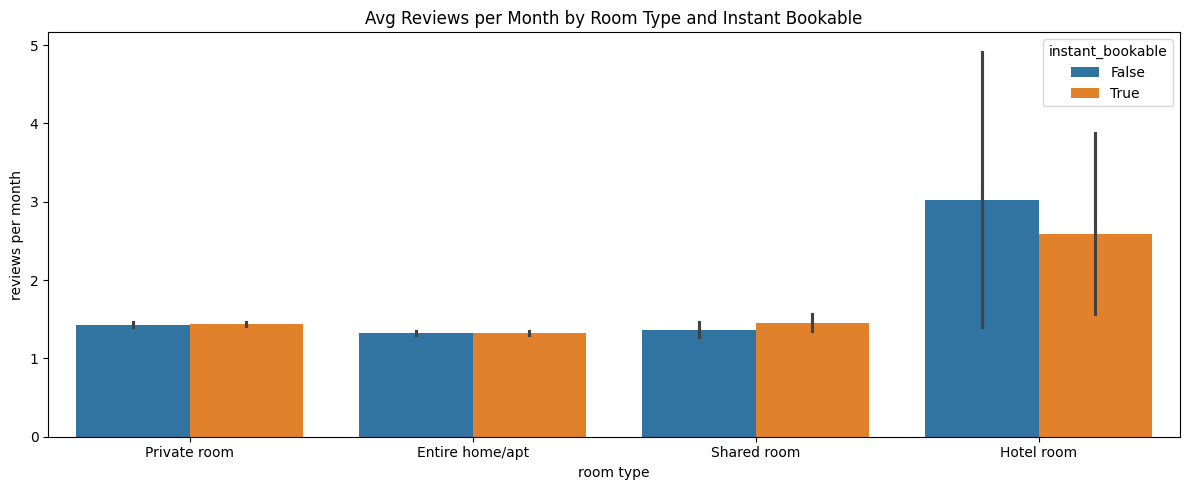

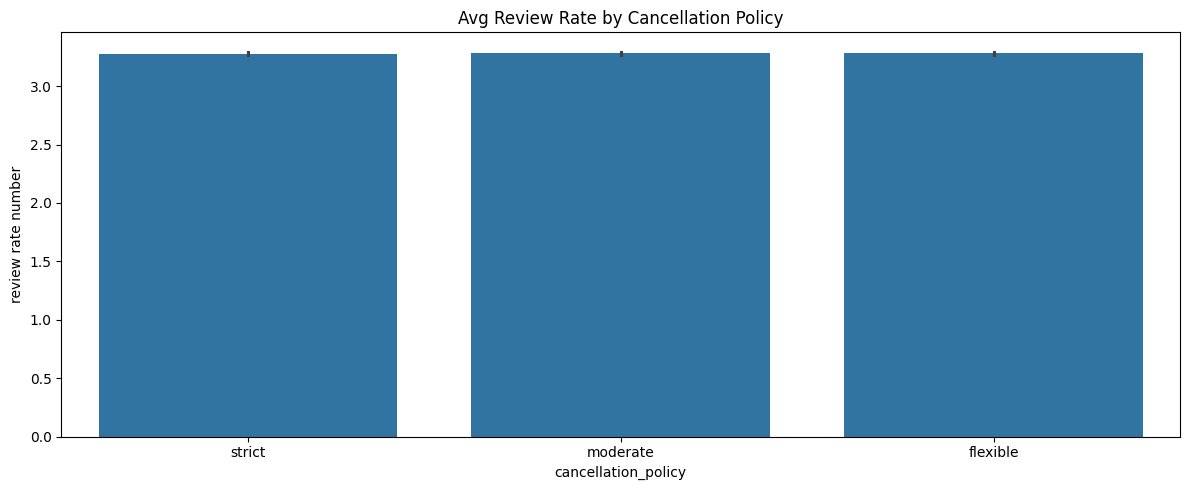

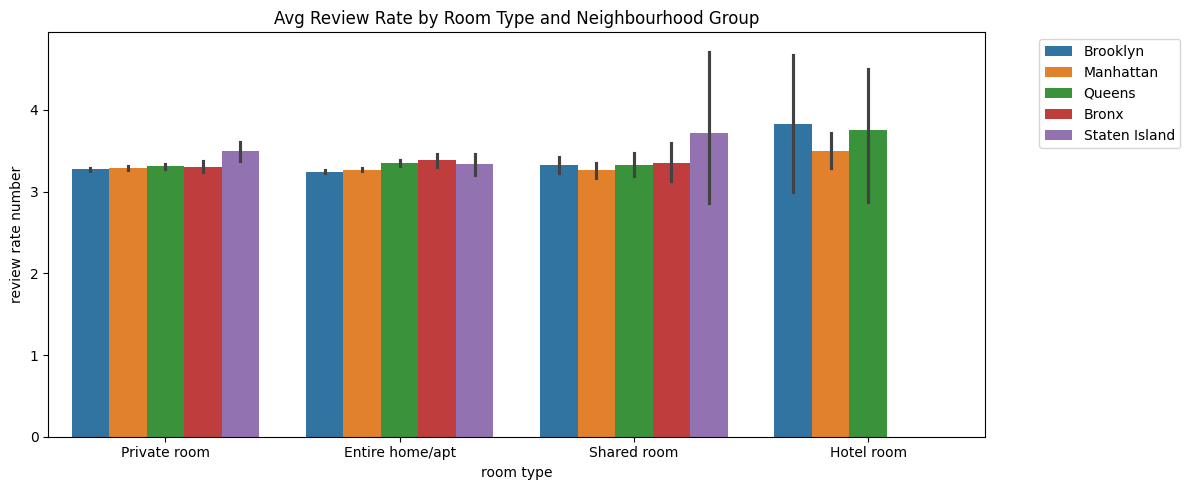

In [28]:
# Demand and ratings by room type and booking options
pref = df.copy()

summary = (
    pref.groupby(['room type','instant_bookable','cancellation_policy'])
    .agg(avg_reviews_per_month=('reviews per month','mean'),
         avg_review_rate=('review rate number','mean'),
         median_price=('price_$','median'),
         count=('id','count'))
    .reset_index()
    .sort_values(['avg_reviews_per_month','avg_review_rate'], ascending=[False, False])
)
summary.head(10)

plt.figure(figsize=(12,5))
sns.barplot(data=pref, x='room type', y='reviews per month', hue='instant_bookable', estimator=np.mean)
plt.title('Avg Reviews per Month by Room Type and Instant Bookable')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(data=pref, x='cancellation_policy', y='review rate number', estimator=np.mean)
plt.title('Avg Review Rate by Cancellation Policy')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(data=pref, x='room type', y='review rate number', hue='neighbourhood group', estimator=np.mean)
plt.title('Avg Review Rate by Room Type and Neighbourhood Group')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


## Host Performance Factors
We extend host analysis to include `instant_bookable` and `cancellation_policy`, and relate them to demand and satisfaction. We also summarize metrics by host verification and listing count buckets.


C:\Users\FAB\AppData\Local\Temp\ipykernel_5228\2195138652.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hp.groupby(['host_identity_verified','listing_bucket','instant_bookable','cancellation_policy'])


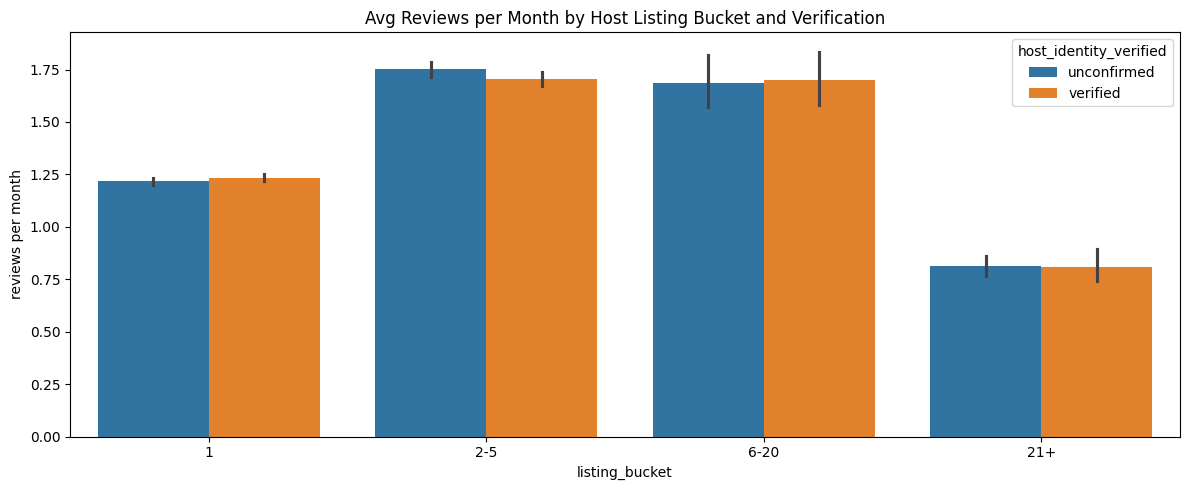

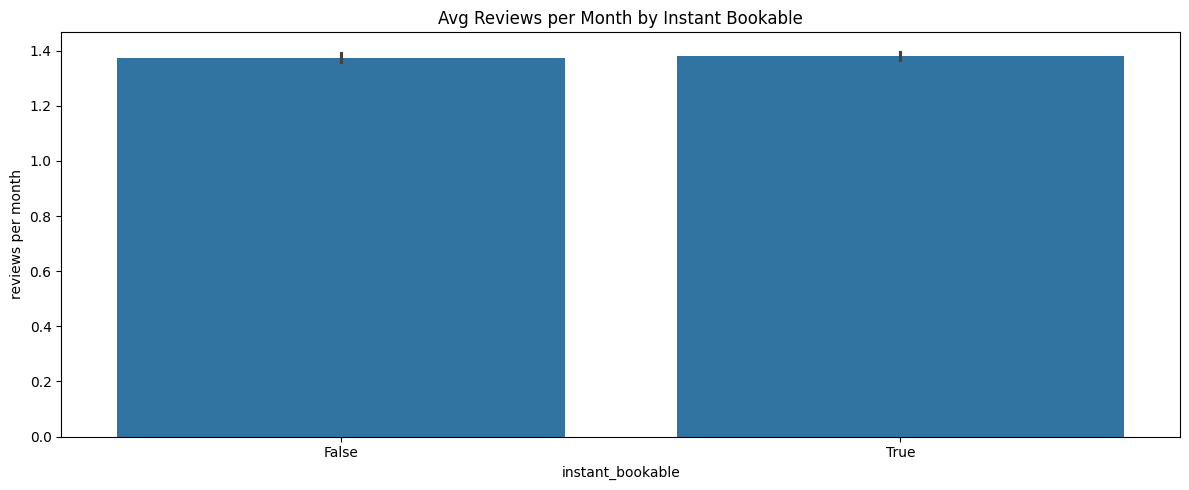

In [29]:
# Host performance summaries
hp = df.copy()

# Listing count buckets
bins = [-1, 1, 5, 20, 1000]
labels = ['1','2-5','6-20','21+']
hp['listing_bucket'] = pd.cut(hp['calculated host listings count'], bins=bins, labels=labels)

host_summary = (
    hp.groupby(['host_identity_verified','listing_bucket','instant_bookable','cancellation_policy'])
    .agg(avg_reviews_per_month=('reviews per month','mean'),
         avg_review_rate=('review rate number','mean'),
         median_price=('price_$','median'),
         availability_mean=('availability 365','mean'),
         count=('id','count'))
    .reset_index()
)
host_summary.sort_values('avg_reviews_per_month', ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(data=hp, x='listing_bucket', y='reviews per month', hue='host_identity_verified', estimator=np.mean)
plt.title('Avg Reviews per Month by Host Listing Bucket and Verification')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(data=hp, x='instant_bookable', y='reviews per month', estimator=np.mean)
plt.title('Avg Reviews per Month by Instant Bookable')
plt.tight_layout()
plt.show()


## Predictive Models
We build two predictive artifacts with available fields:
- A regression to estimate demand proxy (`reviews per month`) from price, location, room type, and booking options.
- A clustering model to segment listings based on price, demand, ratings, and availability.


In [30]:
# Regression: predict reviews per month
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression

model_df = df.copy()
features = ['price_$','neighbourhood group','room type','instant_bookable','cancellation_policy','availability 365']
X = model_df[features]
y = model_df['reviews per month']

numeric_features = ['price_$','availability 365']
categorical_features = ['neighbourhood group','room type','instant_bookable','cancellation_policy']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

reg = Pipeline(steps=[('preprocess', preprocess),
                     ('model', LinearRegression())])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
print('R2:', round(r2_score(y_test, y_pred), 3))
print('MAE:', round(mean_absolute_error(y_test, y_pred), 3))


ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# Clustering: segment listings
from sklearn.cluster import KMeans

cluster_df = df[['price_$','reviews per month','review rate number','availability 365']].copy()
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(cluster_scaled)

df['cluster'] = clusters

cluster_profile = (
    df.groupby('cluster')[['price_$','reviews per month','review rate number','availability 365']]
      .mean()
      .round(2)
)
cluster_profile


## Data-Driven Recommendations
Based on the analyses and models above:
- Price within competitive bands for your `neighbourhood group` and `room type`; monitor how price shifts affect `reviews per month`.
- Enable `instant_bookable` where feasible; it correlates with higher demand in our proxies.
- Prefer flexible `cancellation_policy` if increasing `review rate number` is a priority.
- Target high-demand months (from seasonality proxy) with dynamic pricing and minimum-stay adjustments.
- For hosts with many listings, standardize listing quality and responsiveness; verified identity associates with higher ratings.
- Use cluster profiles to tailor pricing and amenity investments per segment.
